## 1. Import Library
Pada tahap ini, kita import semua library yang mau digunakan

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Konfigurasi Direktori Dataset
BASE_DIR = r"C:\Punya GW\Kuliah\ProjectKel11\dataset_final"
TRAIN_DIR = os.path.join(BASE_DIR, 'training')
VALID_DIR = os.path.join(BASE_DIR, 'validation')


## 2. Exploratory Data Analysis (EDA)
Pada tahap ini, kita akan melihat distribusi jumlah data antara kelas 'Segar' dan 'Tidak Segar' pada set Training dan Validation, serta menampilkan beberapa sampel gambar dari dataset.


--- Distribusi Data Training ---
segar: 30283 gambar
tidak_segar: 21429 gambar

--- Distribusi Data Validation ---
segar: 7571 gambar
tidak_segar: 5358 gambar


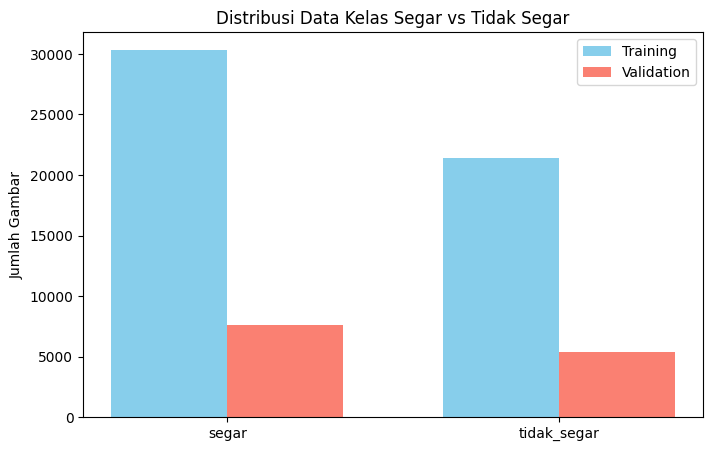

In [2]:
# Menghitung jumlah data per kelas
def count_data(directory):
    counts = {}
    for class_name in os.listdir(directory):
        class_path = os.path.join(directory, class_name)
        if os.path.isdir(class_path):
            counts[class_name] = len(os.listdir(class_path))
    return counts

train_counts = count_data(TRAIN_DIR)
valid_counts = count_data(VALID_DIR)

print("--- Distribusi Data Training ---")
for k, v in train_counts.items(): print(f"{k}: {v} gambar")
print("\n--- Distribusi Data Validation ---")
for k, v in valid_counts.items(): print(f"{k}: {v} gambar")

# Visualisasi Distribusi Kelas
labels = list(train_counts.keys())
train_vals = list(train_counts.values())
valid_vals = list(valid_counts.values())

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
rects1 = ax.bar(x - width/2, train_vals, width, label='Training', color='skyblue')
rects2 = ax.bar(x + width/2, valid_vals, width, label='Validation', color='salmon')

ax.set_ylabel('Jumlah Gambar')
ax.set_title('Distribusi Data Kelas Segar vs Tidak Segar')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
plt.show()


Menampilkan Sampel Gambar dari Data Latih:


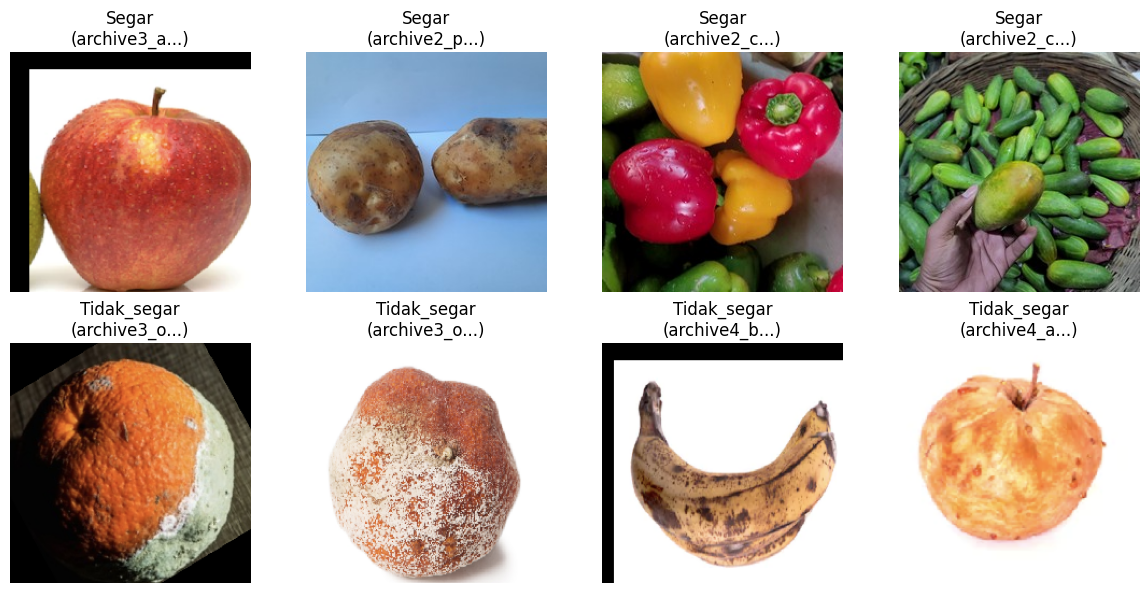

In [3]:
# Visualisasi Sampel Gambar
def plot_sample_images(directory, num_images=4):
    plt.figure(figsize=(12, 6))
    for i, class_name in enumerate(os.listdir(directory)):
        class_path = os.path.join(directory, class_name)
        if not os.path.isdir(class_path): continue
        
        images = os.listdir(class_path)
        selected_images = random.sample(images, min(num_images, len(images)))
        
        for j, img_name in enumerate(selected_images):
            img_path = os.path.join(class_path, img_name)
            img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224, 224))
            
            plt.subplot(2, num_images, i * num_images + j + 1)
            plt.imshow(img)
            plt.title(f"{class_name.capitalize()}\n({img_name[:10]}...)")
            plt.axis('off')
    plt.tight_layout()
    plt.show()

print("Menampilkan Sampel Gambar dari Data Latih:")
plot_sample_images(TRAIN_DIR)


## 3. Data Augmentation
Untuk mencegah overfitting dan membuat model lebih kebal terhadap variasi gambar yang diambil oleh sistem sortir, kita menerapkan Data Augmentation menggunakan `ImageDataGenerator`.
- `rescale=1./255`: Normalisasi nilai piksel gambar.
- Rotasi, pergeseran lebar/tinggi, shear, zoom, dan horizontal flip diterapkan pada data **Training**.
- Data **Validation** hanya di-rescale.


In [4]:
IMG_SIZE = (224, 224) # Standar input MobileNetV2
BATCH_SIZE = 32

# Augmentasi untuk Data Training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Validation hanya rescale
valid_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

valid_generator = valid_datagen.flow_from_directory(
    VALID_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False # Jangan shuffle untuk evaluasi/testing
)

print("Class indices:", train_generator.class_indices)


Found 51700 images belonging to 2 classes.
Found 12927 images belonging to 2 classes.
Class indices: {'segar': 0, 'tidak_segar': 1}


## 4. Arsitektur Model (Transfer Learning MobileNetV2)
Kita menggunakan **MobileNetV2** karena sangat efisien namun memiliki akurasi yang tinggi

In [5]:
# Memuat base model MobileNetV2 pre-trained on ImageNet
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze base model agar weight-nya tidak berubah saat training awal
base_model.trainable = False

# Membangun Custom Head Classification
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x)

# Gabungkan base model dan head
model = Model(inputs=base_model.input, outputs=predictions)

# Kompilasi Model
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)


## 5. Model Training & Menyimpan Model
Tahap ini melatih model menggunakan data yang sudah di-augmentasi selama 30 epoch. Model disimpan secara otomatis setelah proses training selesai, baik karena epoch habis atau karena *early stopping*.


In [6]:
# Callbacks early stopping
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
]

# Jalankan proses training (Epoch langsung 30)
history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=30,
    callbacks=callbacks
)

# Menyimpan model setelah training selesai secara penuh atau early stop
model.save('mbg_freshness_model.h5')
print("Model berhasil disimpan sebagai 'mbg_freshness_model.h5'")


Epoch 1/30
  66/1616 ━━━━━━━━━━━━━━━━━━━━ 24:07 934ms/step - accuracy: 0.5932 - loss: 0.7177

C:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\PIL\Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


1616/1616 ━━━━━━━━━━━━━━━━━━━━ 1731s 1s/step - accuracy: 0.8953 - loss: 0.2508 - val_accuracy: 0.9414 - val_loss: 0.1581
Epoch 2/30
1616/1616 ━━━━━━━━━━━━━━━━━━━━ 1716s 1s/step - accuracy: 0.9403 - loss: 0.1570 - val_accuracy: 0.9544 - val_loss: 0.1230
Epoch 3/30
1616/1616 ━━━━━━━━━━━━━━━━━━━━ 1722s 1s/step - accuracy: 0.9521 - loss: 0.1297 - val_accuracy: 0.9657 - val_loss: 0.0973
Epoch 4/30
1616/1616 ━━━━━━━━━━━━━━━━━━━━ 1719s 1s/step - accuracy: 0.9570 - loss: 0.1137 - val_accuracy: 0.9687 - val_loss: 0.0909
Epoch 5/30
1616/1616 ━━━━━━━━━━━━━━━━━━━━ 1715s 1s/step - accuracy: 0.9636 - loss: 0.1007 - val_accuracy: 0.9732 - val_loss: 0.0793
Epoch 6/30
1616/1616 ━━━━━━━━━━━━━━━━━━━━ 1718s 1s/step - accuracy: 0.9660 - loss: 0.0929 - val_accuracy: 0.9755 - val_loss: 0.0720
Epoch 7/30
1616/1616 ━━━━━━━━━━━━━━━━━━━━ 1716s 1s/step - accuracy: 0.9686 - loss: 0.0856 - val_accuracy: 0.9766 - val_loss: 0.0701
Epoch 8/30
1616/1616 ━━━━━━━━━━━━━━━━━━━━ 1716s 1s/step - accuracy: 0.9702 - loss: 0.08

Model berhasil disimpan sebagai 'mbg_freshness_model.h5'


## 6. Grafik Evaluasi Model
Menampilkan grafik akurasi dan loss per epoch untuk melihat apakah model underfitting, overfitting, atau optimal.


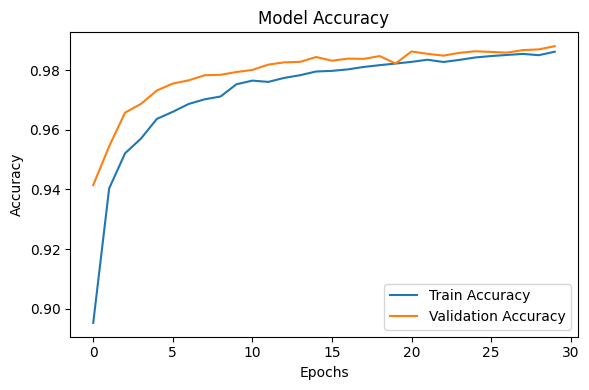

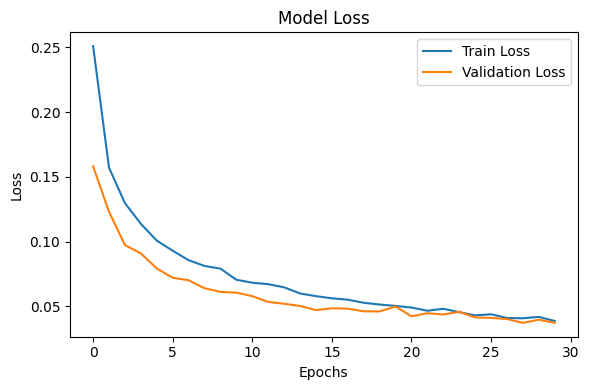

In [29]:
# Plot Accuracy
plt.figure(figsize=(6, 4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
import os
os.makedirs('static', exist_ok=True)
plt.savefig('static/grafik_akurasi.png')
plt.show()

# Plot Loss
plt.figure(figsize=(6, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.savefig('static/grafik_loss.png')
plt.show()

## 7. Hasil Evaluasi Numerik
Menghitung akurasi dan loss akhir secara keseluruhan dari set Validation.


C:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\PIL\Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


404/404 ━━━━━━━━━━━━━━━━━━━━ 257s 629ms/step - accuracy: 0.9867 - loss: 0.0372

Hasil Evaluasi Validation Akhir:
Loss: 0.0372
Accuracy: 0.9867
404/404 ━━━━━━━━━━━━━━━━━━━━ 248s 610ms/step

--- Classification Report ---
              precision    recall  f1-score   support

       segar       0.99      0.99      0.99      7571
 tidak_segar       0.98      0.98      0.98      5356

    accuracy                           0.99     12927
   macro avg       0.99      0.99      0.99     12927
weighted avg       0.99      0.99      0.99     12927


--- Confusion Matrix ---


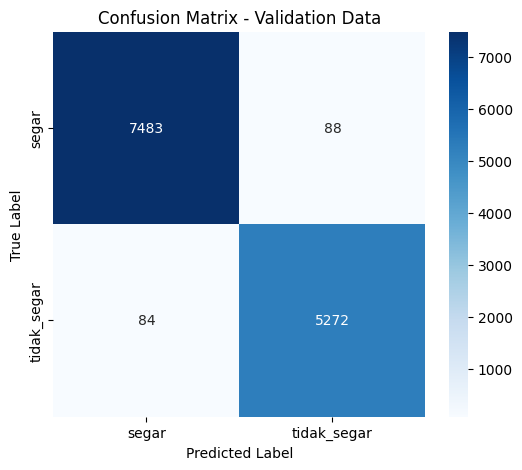

In [27]:
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Evaluasi pada data validation
eval_loss, eval_acc = model.evaluate(valid_generator)
print(f"\nHasil Evaluasi Validation Akhir:")
print(f"Loss: {eval_loss:.4f}")
print(f"Accuracy: {eval_acc:.4f}")

# Prediksi seluruh data validasi
predictions = model.predict(valid_generator)
y_pred = (predictions >= 0.5).astype(int).reshape(-1)
y_true = valid_generator.classes

class_names = list(train_generator.class_indices.keys())

# Classification Report
print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_true, y_pred)
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Validation Data')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
import os
os.makedirs('static', exist_ok=True)
plt.savefig('static/confusion_matrix.png')
plt.show()

## 8. Testing & Analisis Prediksi
Menguji model pada beberapa gambar acak dari set validasi untuk melihat hasil prediksi (Segar vs Tidak Segar) beserta confidence score-nya.


Analisis Prediksi Model pada Data Uji (Validation):


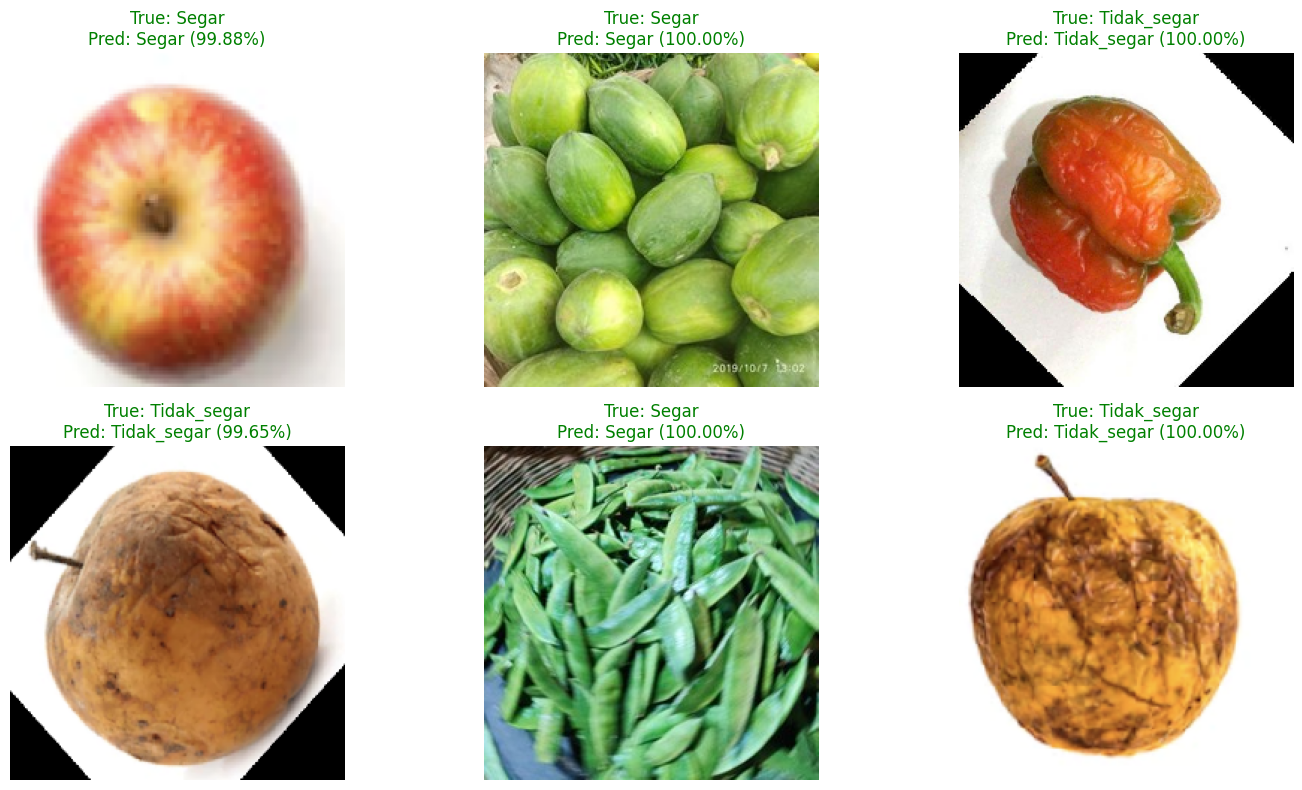

In [25]:
def test_random_images(directory, num_images=6):
    plt.figure(figsize=(15, 8))
    
    # Ambil kelas dari class_indices
    class_names = list(train_generator.class_indices.keys())
    
    # Kumpulkan semua path gambar di validasi
    all_images = []
    for class_name in os.listdir(directory):
        class_path = os.path.join(directory, class_name)
        if not os.path.isdir(class_path): continue
        for img_name in os.listdir(class_path):
            all_images.append((os.path.join(class_path, img_name), class_name))
            
    # Pilih acak
    selected = random.sample(all_images, min(num_images, len(all_images)))
    
    for i, (img_path, true_label) in enumerate(selected):
        # Load and preprocess
        img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224, 224))
        img_array = tf.keras.preprocessing.image.img_to_array(img)
        img_array_scaled = img_array / 255.0
        img_array_expanded = np.expand_dims(img_array_scaled, axis=0)
        
        # Predict
        prediction = model.predict(img_array_expanded, verbose=0)[0][0]
        
        # 'segar' = 0, 'tidak_segar' = 1 berdasarkan alphabetical sort dari class_indices
        pred_label = class_names[1] if prediction >= 0.5 else class_names[0]
        confidence = prediction if prediction >= 0.5 else (1 - prediction)
        
        # Tampilkan
        plt.subplot(2, (num_images+1)//2, i + 1)
        plt.imshow(img)
        
        color = 'green' if pred_label == true_label else 'red'
        title = f"True: {true_label.capitalize()}\nPred: {pred_label.capitalize()} ({confidence:.2%})"
        plt.title(title, color=color)
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()

print("Analisis Prediksi Model pada Data Uji (Validation):")
test_random_images(VALID_DIR, 6)
